DATASET STRUCTURE ANALYSIS

TRAIN SET:
  NORMAL: 2300 images
  CSR: 2300 images

TEST SET:
  NORMAL: 350 images
  CSR: 350 images

VAL SET:
  NORMAL: 350 images
  CSR: 350 images


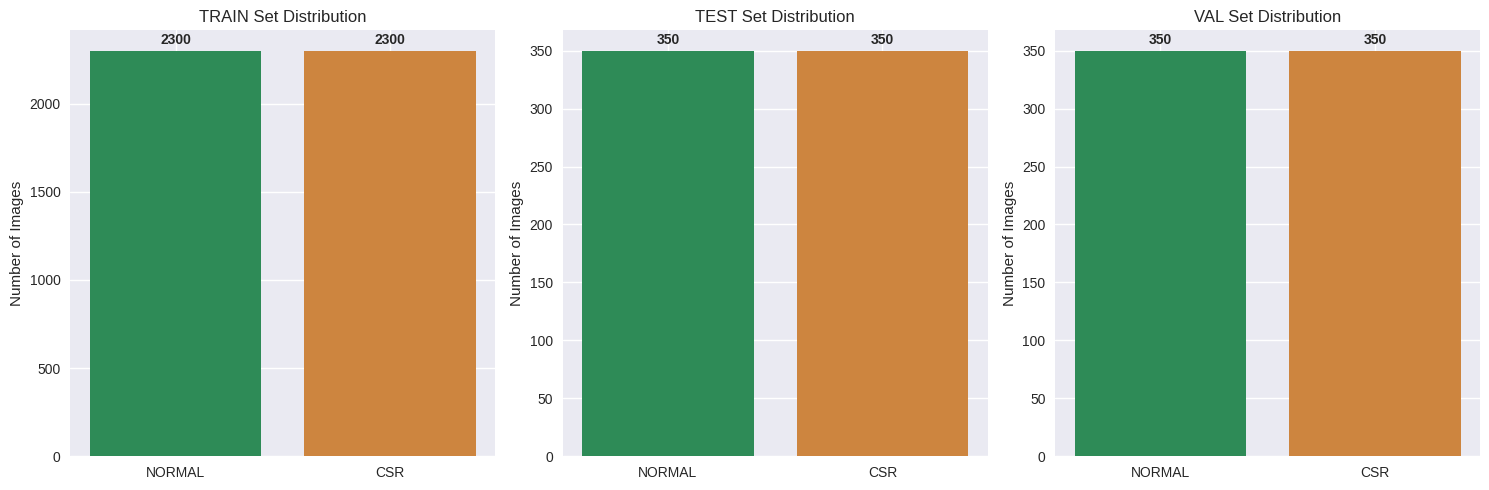


IMAGE PROPERTIES ANALYSIS

Analyzed 60 images

Image Dimensions:
Width - Min: 512, Max: 1536, Mean: 695.1
Height - Min: 496, Max: 586, Mean: 509.3

File Sizes (KB):
Min: 27.9, Max: 121.4, Mean: 59.2

Color Channels: {1: 30, 3: 30}


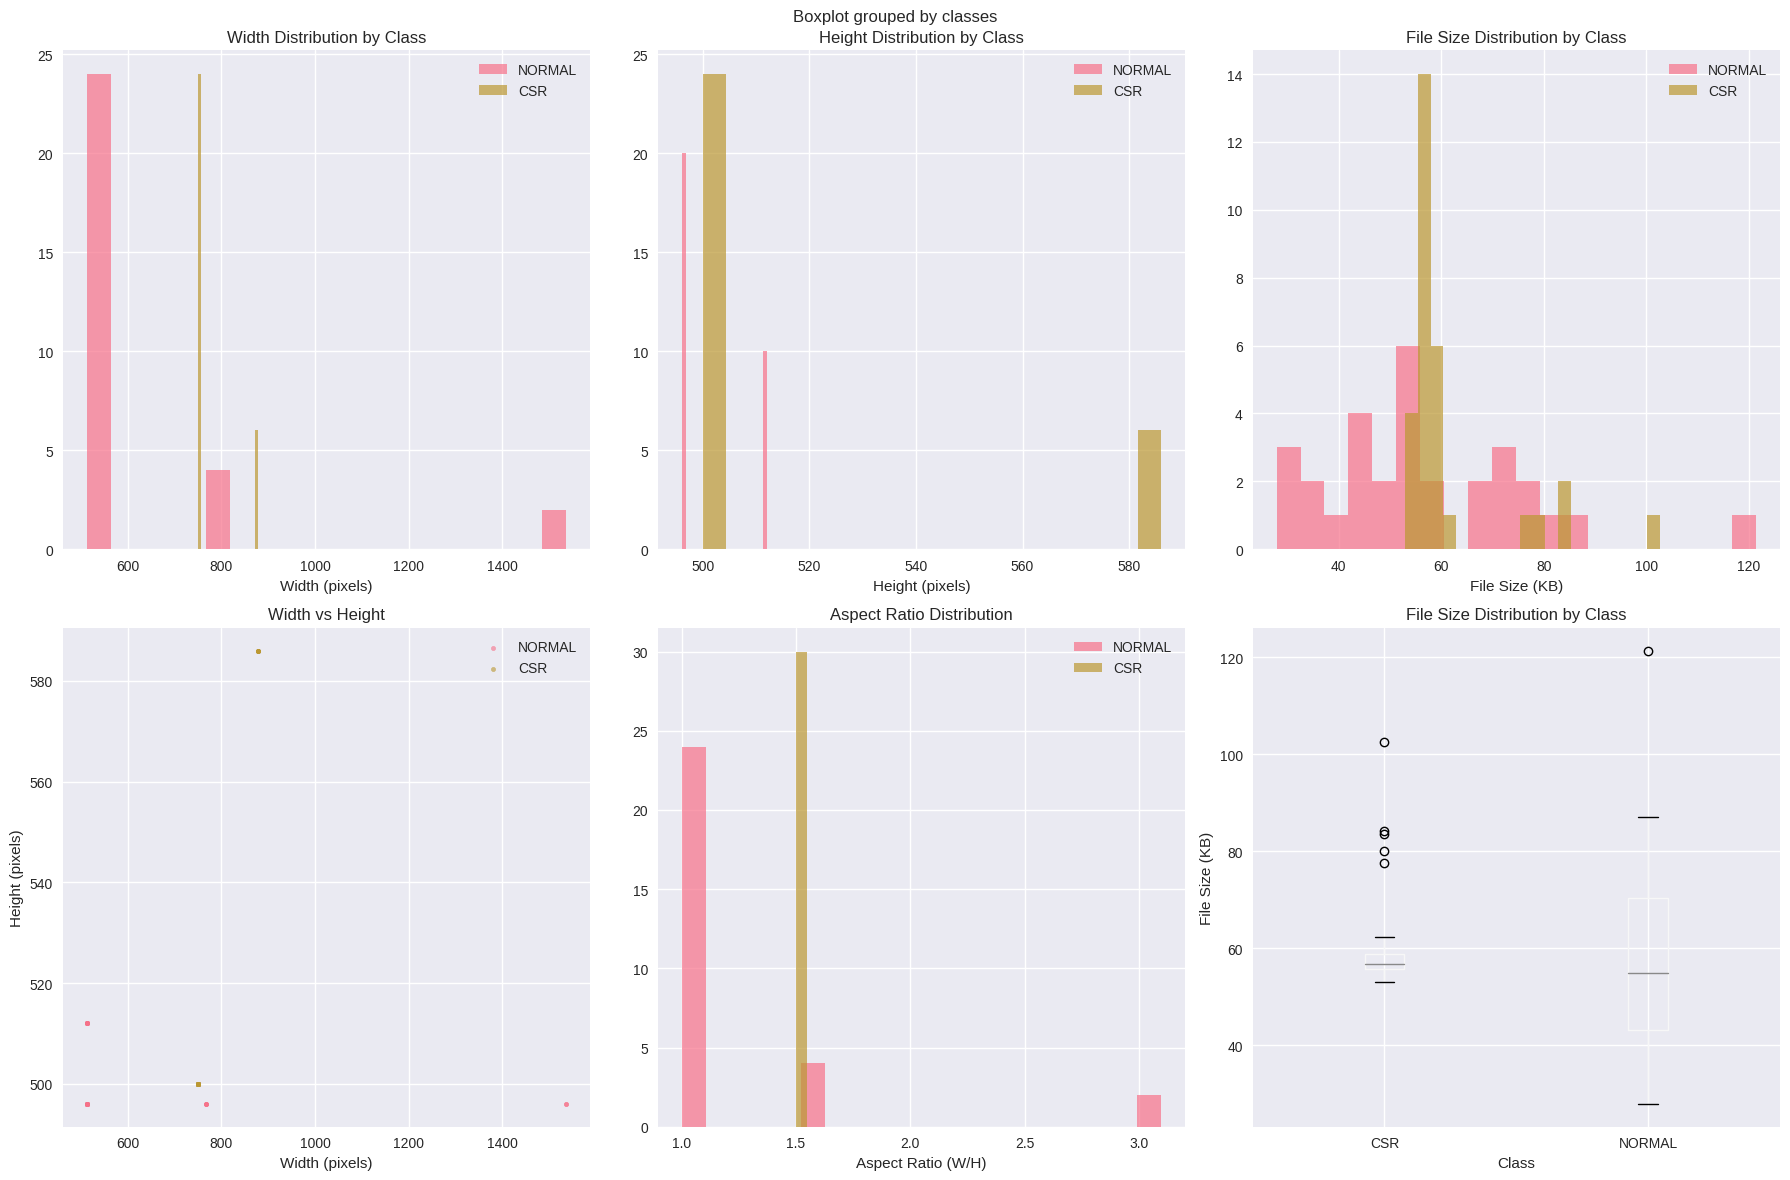

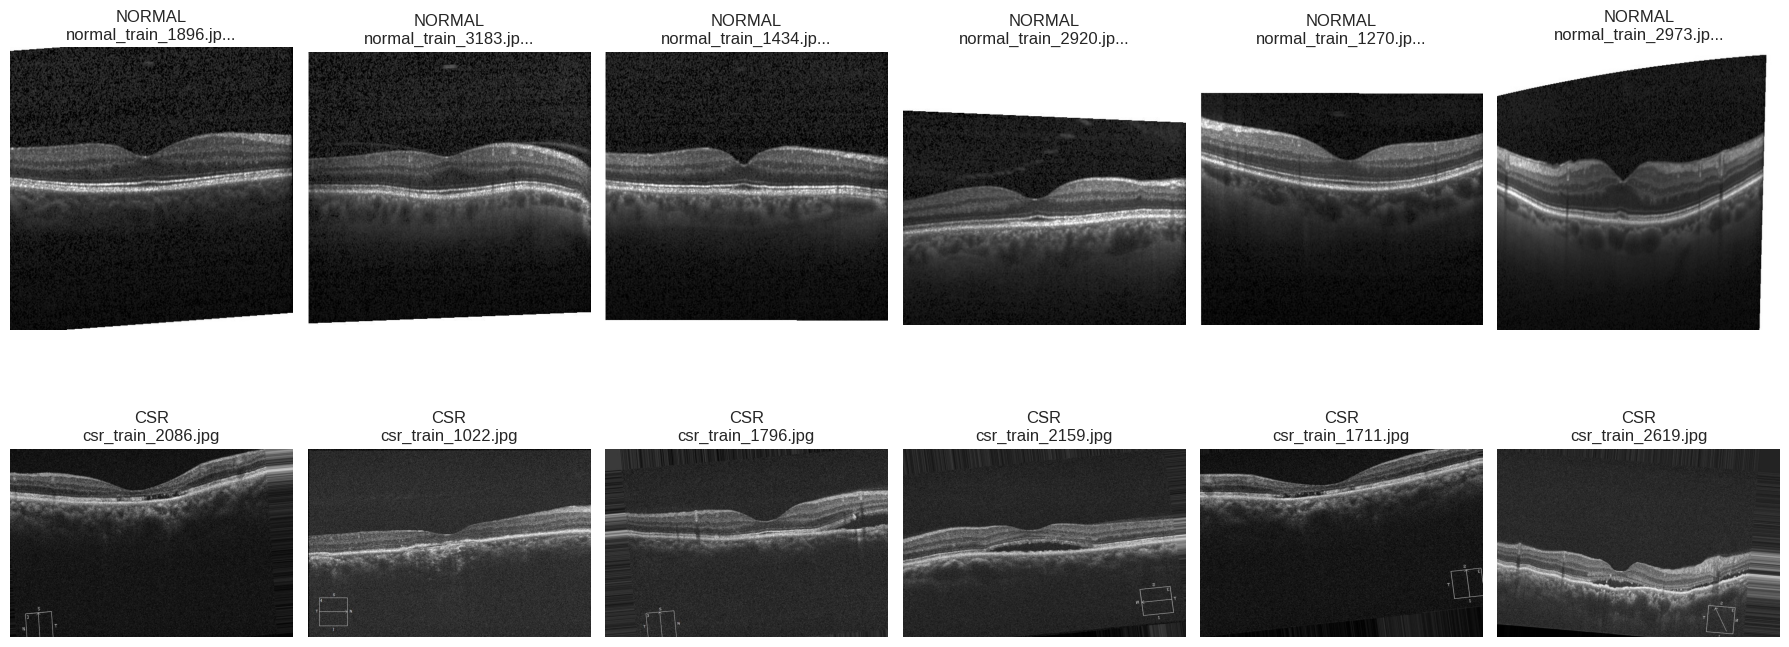


PIXEL INTENSITY ANALYSIS


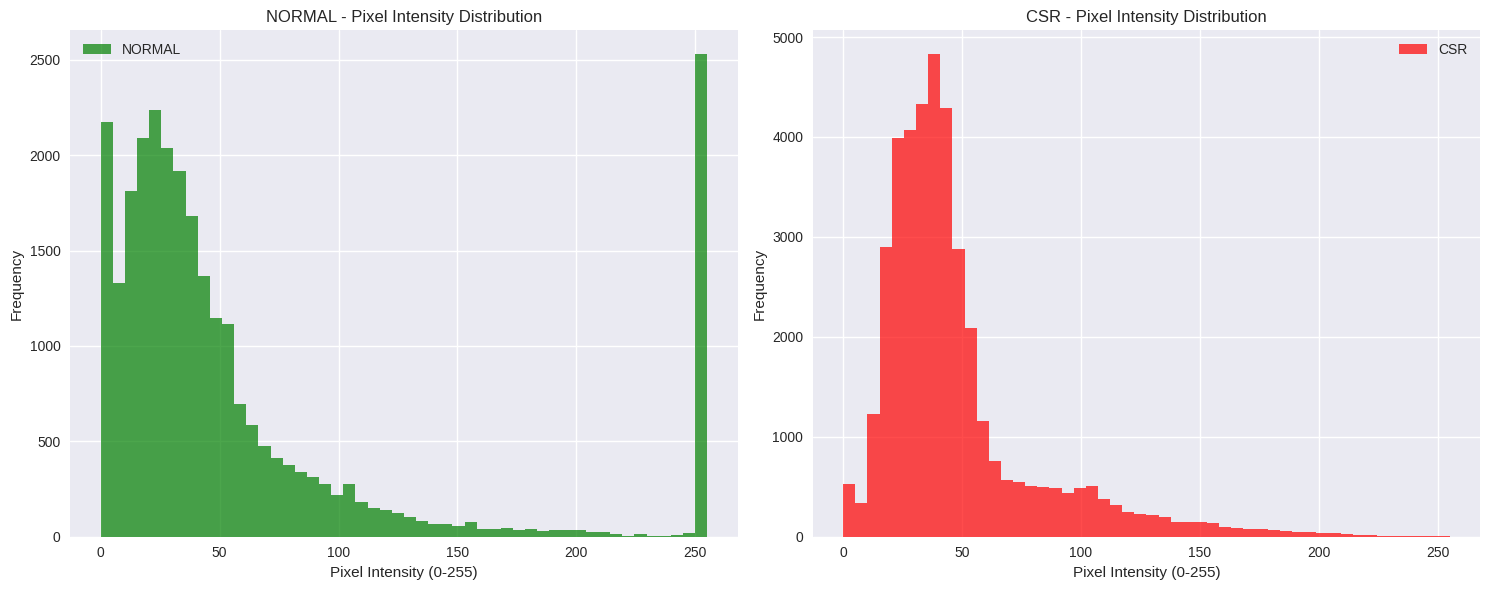


Pixel Intensity Statistics:
       mean_intensity        std_intensity       
                 mean    std          mean    std
class                                            
CSR             46.83   8.63         32.89   2.27
NORMAL          62.19  22.49         65.41  23.29

COMPREHENSIVE EDA SUMMARY REPORT

   Total Images: 6000
   Classes: NORMAL, CSR
   Splits: train, test, val
CLASS DISTRIBUTION:
   TRAIN:
     NORMAL: 2300 images (50.0%)
     CSR: 2300 images (50.0%)
   TEST:
     NORMAL: 350 images (50.0%)
     CSR: 350 images (50.0%)
   VAL:
     NORMAL: 350 images (50.0%)
     CSR: 350 images (50.0%)
EDA Complete! Review the plots and statistics above.


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class RetinalOCTEDA:
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.data_info = {}
        
    def analyze_dataset_structure(self):
        """Analyze the overall dataset structure"""
        print("="*50)
        print("DATASET STRUCTURE ANALYSIS")
        print("="*50)
        
        splits = ['train', 'test', 'val']
        classes = ['NORMAL', 'CSR']  # Focus on these two classes
        
        for split in splits:
            # Updated path structure for your dataset
            split_path = os.path.join(self.dataset_path, 'RetinalOCT_Dataset', 'RetinalOCT_Dataset', split)
            if os.path.exists(split_path):
                print(f"\n{split.upper()} SET:")
                self.data_info[split] = {}
                
                for class_name in classes:
                    class_path = os.path.join(split_path, class_name)
                    if os.path.exists(class_path):
                        image_files = [f for f in os.listdir(class_path) 
                                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
                        count = len(image_files)
                        self.data_info[split][class_name] = {
                            'count': count,
                            'path': class_path,
                            'files': image_files[:10]  # Store first 10 filenames
                        }
                        print(f"  {class_name}: {count} images")
                    else:
                        print(f"  {class_name}: Directory not found")
                        
            # Also check if val folder exists, if not, mention it
            elif split == 'val':
                print(f"\n{split.upper()} SET: Not found (you may need to create validation split from train)")
        
        return self.data_info
    
    def plot_class_distribution(self):
        """Plot class distribution across splits"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        splits = ['train', 'test', 'val']
        for i, split in enumerate(splits):
            if split in self.data_info:
                classes = list(self.data_info[split].keys())
                counts = [self.data_info[split][cls]['count'] for cls in classes]
                
                axes[i].bar(classes, counts, color=['#2E8B57', '#CD853F'])
                axes[i].set_title(f'{split.upper()} Set Distribution')
                axes[i].set_ylabel('Number of Images')
                
                # Add count labels on bars
                for j, count in enumerate(counts):
                    axes[i].text(j, count + max(counts)*0.01, str(count), 
                               ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    def analyze_image_properties(self, sample_size=100):
        """Analyze image properties like dimensions, file sizes, etc."""
        print("\n" + "="*50)
        print("IMAGE PROPERTIES ANALYSIS")
        print("="*50)
        
        image_stats = {
            'widths': [], 'heights': [], 'file_sizes': [], 
            'channels': [], 'classes': [], 'splits': []
        }
        
        for split in self.data_info:
            for class_name in self.data_info[split]:
                class_path = self.data_info[split][class_name]['path']
                files = self.data_info[split][class_name]['files']
                
                # Sample random images for analysis
                sample_files = files[:min(sample_size, len(files))]
                
                for filename in sample_files:
                    filepath = os.path.join(class_path, filename)
                    
                    try:
                        # Get file size
                        file_size = os.path.getsize(filepath) / 1024  # KB
                        
                        # Get image properties
                        with Image.open(filepath) as img:
                            width, height = img.size
                            channels = len(img.getbands()) if img.mode != 'L' else 1
                            
                            image_stats['widths'].append(width)
                            image_stats['heights'].append(height)
                            image_stats['file_sizes'].append(file_size)
                            image_stats['channels'].append(channels)
                            image_stats['classes'].append(class_name)
                            image_stats['splits'].append(split)
                            
                    except Exception as e:
                        print(f"Error processing {filepath}: {e}")
        
        # Convert to DataFrame for easier analysis
        df = pd.DataFrame(image_stats)
        
        # Print statistics
        print(f"\nAnalyzed {len(df)} images")
        print(f"\nImage Dimensions:")
        print(f"Width - Min: {df['widths'].min()}, Max: {df['widths'].max()}, Mean: {df['widths'].mean():.1f}")
        print(f"Height - Min: {df['heights'].min()}, Max: {df['heights'].max()}, Mean: {df['heights'].mean():.1f}")
        print(f"\nFile Sizes (KB):")
        print(f"Min: {df['file_sizes'].min():.1f}, Max: {df['file_sizes'].max():.1f}, Mean: {df['file_sizes'].mean():.1f}")
        print(f"\nColor Channels: {df['channels'].value_counts().to_dict()}")
        
        return df
    
    def plot_image_properties(self, df):
        """Plot image properties distributions"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Width distribution by class
        for class_name in df['classes'].unique():
            subset = df[df['classes'] == class_name]
            axes[0,0].hist(subset['widths'], alpha=0.7, label=class_name, bins=20)
        axes[0,0].set_title('Width Distribution by Class')
        axes[0,0].set_xlabel('Width (pixels)')
        axes[0,0].legend()
        
        # Height distribution by class
        for class_name in df['classes'].unique():
            subset = df[df['classes'] == class_name]
            axes[0,1].hist(subset['heights'], alpha=0.7, label=class_name, bins=20)
        axes[0,1].set_title('Height Distribution by Class')
        axes[0,1].set_xlabel('Height (pixels)')
        axes[0,1].legend()
        
        # File size distribution
        for class_name in df['classes'].unique():
            subset = df[df['classes'] == class_name]
            axes[0,2].hist(subset['file_sizes'], alpha=0.7, label=class_name, bins=20)
        axes[0,2].set_title('File Size Distribution by Class')
        axes[0,2].set_xlabel('File Size (KB)')
        axes[0,2].legend()
        
        # Width vs Height scatter
        for class_name in df['classes'].unique():
            subset = df[df['classes'] == class_name]
            axes[1,0].scatter(subset['widths'], subset['heights'], 
                            alpha=0.6, label=class_name, s=10)
        axes[1,0].set_title('Width vs Height')
        axes[1,0].set_xlabel('Width (pixels)')
        axes[1,0].set_ylabel('Height (pixels)')
        axes[1,0].legend()
        
        # Aspect ratio distribution
        df['aspect_ratio'] = df['widths'] / df['heights']
        for class_name in df['classes'].unique():
            subset = df[df['classes'] == class_name]
            axes[1,1].hist(subset['aspect_ratio'], alpha=0.7, label=class_name, bins=20)
        axes[1,1].set_title('Aspect Ratio Distribution')
        axes[1,1].set_xlabel('Aspect Ratio (W/H)')
        axes[1,1].legend()
        
        # Box plot of file sizes by class
        df.boxplot(column='file_sizes', by='classes', ax=axes[1,2])
        axes[1,2].set_title('File Size Distribution by Class')
        axes[1,2].set_xlabel('Class')
        axes[1,2].set_ylabel('File Size (KB)')
        
        plt.tight_layout()
        plt.show()
    
    def display_sample_images(self, num_samples=6):
        """Display sample images from each class"""
        fig, axes = plt.subplots(2, num_samples, figsize=(18, 8))
        
        classes = ['NORMAL', 'CSR']
        
        for i, class_name in enumerate(classes):
            # Get images from train set
            if 'train' in self.data_info and class_name in self.data_info['train']:
                class_path = self.data_info['train'][class_name]['path']
                files = self.data_info['train'][class_name]['files']
                
                for j in range(min(num_samples, len(files))):
                    filepath = os.path.join(class_path, files[j])
                    
                    try:
                        img = cv2.imread(filepath)
                        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        
                        axes[i, j].imshow(img_rgb)
                        axes[i, j].axis('off')
                        axes[i, j].set_title(f'{class_name}\n{files[j][:20]}...' if len(files[j]) > 20 else f'{class_name}\n{files[j]}')
                        
                    except Exception as e:
                        axes[i, j].text(0.5, 0.5, f'Error loading\n{files[j]}', 
                                       ha='center', va='center', transform=axes[i, j].transAxes)
                        axes[i, j].set_title(f'{class_name} - Error')
        
        plt.tight_layout()
        plt.show()
    
    def analyze_pixel_intensities(self, sample_size=20):
        """Analyze pixel intensity distributions"""
        print("\n" + "="*50)
        print("PIXEL INTENSITY ANALYSIS")
        print("="*50)
        
        intensity_stats = {'class': [], 'mean_intensity': [], 'std_intensity': []}
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        for class_name in ['NORMAL', 'CSR']:
            if 'train' in self.data_info and class_name in self.data_info['train']:
                class_path = self.data_info['train'][class_name]['path']
                files = self.data_info['train'][class_name]['files']
                
                class_intensities = []
                
                for filename in files[:sample_size]:
                    filepath = os.path.join(class_path, filename)
                    
                    try:
                        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                        if img is not None:
                            mean_int = np.mean(img)
                            std_int = np.std(img)
                            
                            intensity_stats['class'].append(class_name)
                            intensity_stats['mean_intensity'].append(mean_int)
                            intensity_stats['std_intensity'].append(std_int)
                            
                            class_intensities.extend(img.flatten()[::100])  # Sample pixels
                    except Exception as e:
                        print(f"Error processing {filepath}: {e}")
                
                # Plot histogram
                if class_name == 'NORMAL':
                    axes[0].hist(class_intensities, bins=50, alpha=0.7, 
                               color='green', label='NORMAL')
                    axes[0].set_title('NORMAL - Pixel Intensity Distribution')
                else:
                    axes[1].hist(class_intensities, bins=50, alpha=0.7, 
                               color='red', label='CSR')
                    axes[1].set_title('CSR - Pixel Intensity Distribution')
        
        for ax in axes:
            ax.set_xlabel('Pixel Intensity (0-255)')
            ax.set_ylabel('Frequency')
            ax.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        stats_df = pd.DataFrame(intensity_stats)
        print("\nPixel Intensity Statistics:")
        print(stats_df.groupby('class').agg({
            'mean_intensity': ['mean', 'std'],
            'std_intensity': ['mean', 'std']
        }).round(2))
    
    def generate_summary_report(self):
        """Generate a comprehensive summary report"""
        print("\n" + "="*60)
        print("COMPREHENSIVE EDA SUMMARY REPORT")
        print("="*60)
        
        total_images = 0
        for split in self.data_info:
            for class_name in self.data_info[split]:
                total_images += self.data_info[split][class_name]['count']
        
        print()
        print(f"   Total Images: {total_images}")
        print(f"   Classes: NORMAL, CSR")
        print(f"   Splits: {', '.join(self.data_info.keys())}")
        
        print(f"CLASS DISTRIBUTION:")
        for split in self.data_info:
            print(f"   {split.upper()}:")
            total_split = sum(self.data_info[split][cls]['count'] for cls in self.data_info[split])
            for class_name in self.data_info[split]:
                count = self.data_info[split][class_name]['count']
                percentage = (count / total_split) * 100 if total_split > 0 else 0
                print(f"     {class_name}: {count} images ({percentage:.1f}%)")
        
        

# Usage Example
def run_eda(dataset_path):
    """Run complete EDA pipeline"""
    eda = RetinalOCTEDA(dataset_path)
    
    # 1. Analyze dataset structure
    eda.analyze_dataset_structure()
    
    
    eda.plot_class_distribution()
    
    
    df = eda.analyze_image_properties()
    
    
    eda.plot_image_properties(df)
    
    
    eda.display_sample_images()
    
    
    eda.analyze_pixel_intensities()
    
    
    eda.generate_summary_report()
    
    return eda

# Run the EDA
if __name__ == "__main__":
    # Updated path for Kaggle dataset
    DATASET_PATH = "/kaggle/input/retinal-oct-c8"
    
    # Run complete EDA
    eda_analyzer = run_eda(DATASET_PATH)
    
    print("EDA Complete! Review the plots and statistics above.")

In [7]:
!pip install tensorflow_quantum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 598.8/598.8 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 91.3 MB/s eta 0:00:00:00:01
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.